In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, ToggleButtons
from google.colab import files
from PIL import Image, ImageOps

Saving cat.jpg to cat (2).jpg


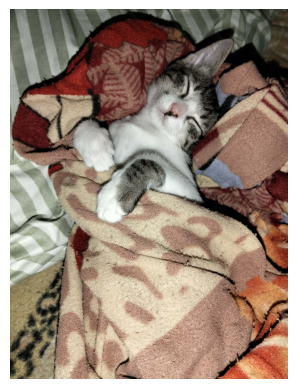

In [ ]:
upload = files.upload()
filename = list(upload.keys())[0]

image = Image.open(filename).convert('RGB')

plt.imshow(image)
plt.axis('off')
plt.show()

In [ ]:
image_np = np.array(image)

h,w = image_np.shape[:2]

#simple else if to with ipython buttons to easily test
#different transforms

def apply_tf(name):
    if name == "Original":
        return image_np
    if name == "Translate":
        M = np.float32([[1, 0, 100], [0, 1, 50]])
        return cv2.warpAffine(image_np, M, (w, h))
    if name == "Rotate 45":
        M = cv2.getRotationMatrix2D((w / 2, h / 2), 45, 1.0)
        return cv2.warpAffine(image_np, M, (w, h))
    if name == "Scale 50%":
        return cv2.resize(image_np, (w // 2, h // 2))
    if name == "Flip H":
        return cv2.flip(image_np, 1)
    if name == "Flip V":
        return cv2.flip(image_np, 0)

NAMES = ["Original", "Translate", "Rotate 45", "Scale 50%", "Flip H", "Flip V"]

def transform(name):# button view
    out = apply_tf(name)
    plt.figure(figsize=(6, 6))
    plt.imshow(out); plt.title(f"{name}   shape={out.shape[:2]}"); plt.axis("off")
    plt.show()

interact(transform, name=ToggleButtons(options=NAMES))

interactive(children=(ToggleButtons(description='name', options=('Original', 'Translate', 'Rotate 45', 'Scale …

<function __main__.transform(name)>

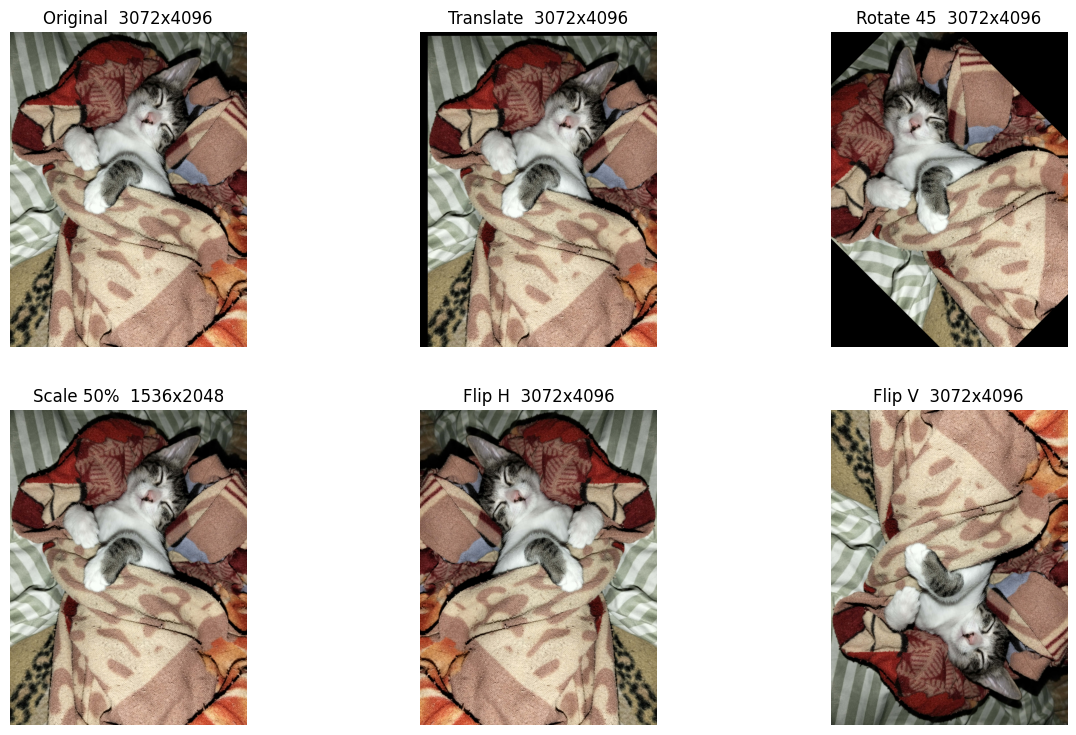

In [ ]:
images = [apply_tf(names) for names in NAMES]

plt.figure(figsize=(15, 9))

for i, (name, out) in enumerate(zip(NAMES, images)):
    plt.subplot(2, 3, i + 1)
    plt.imshow(out)
    plt.title(f"{name}  {out.shape[1]}x{out.shape[0]}")
    plt.axis("off")

plt.show()


Saving rectangle.jpg to rectangle (1).jpg
(2048, 1536, 3)


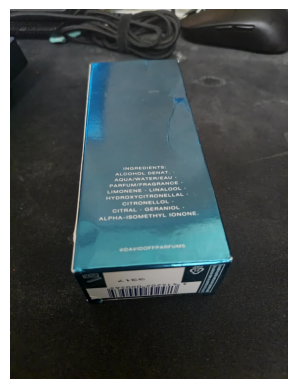

In [ ]:
rec_image = files.upload()
filename = list(rec_image.keys())[0]

#EXIF so rotation flags from cameras are not ignored by PIL
image_rec = ImageOps.exif_transpose(Image.open(filename)).convert('RGB')
rec_np = np.array(image_rec)
h, w = rec_np.shape[:2]
print(rec_np.shape)

plt.imshow(image_rec)
plt.axis('off')
plt.show()

In [ ]:
src = np.float32([[445,300], # TL
                  [919,274],  # TR
                  [1222,1388], # BR
                  [349,1439]])  # BL

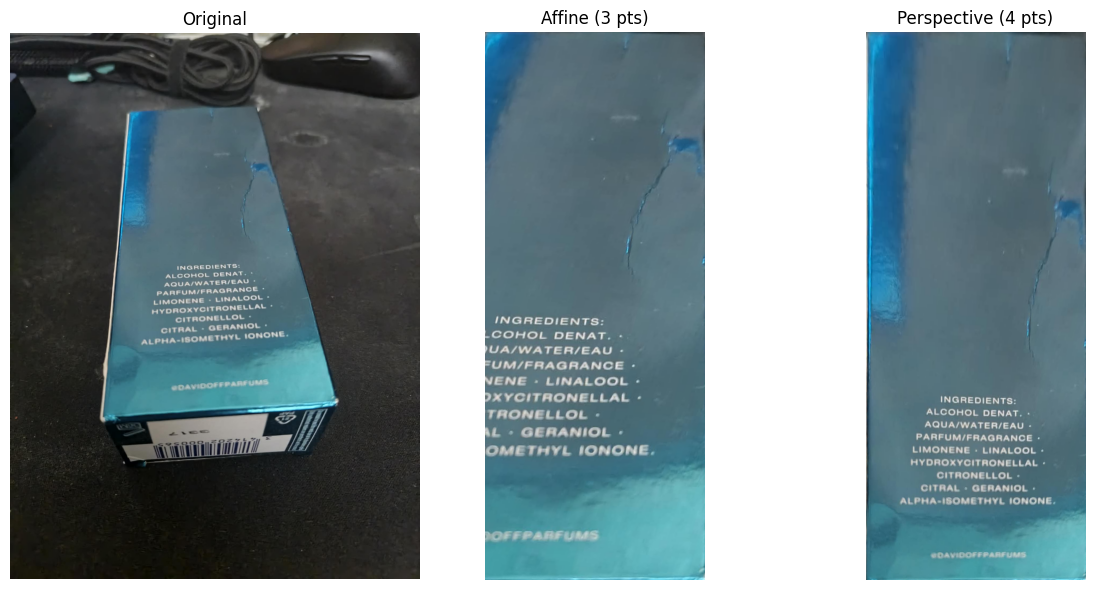

In [ ]:
W, H = 400, 1000 #estimated output dims from box
dst4 = np.float32([[0, 0], [W, 0], [W, H], [0, H]])

#perspective on four points
Mp = cv2.getPerspectiveTransform(src, dst4)
persp = cv2.warpPerspective(rec_np, Mp, (W, H))

#affine on three points
Ma = cv2.getAffineTransform(src[:3], dst4[:3])
aff = cv2.warpAffine(rec_np, Ma, (W, H))

plt.figure(figsize=(12, 6))
for i, (img, t) in enumerate([(rec_np, "Original"), (aff, "Affine (3 pts)"), (persp, "Perspective (4 pts)")]):
    plt.subplot(1, 3, i + 1)
    plt.imshow(img)
    plt.title(t)
    plt.axis("off")

plt.tight_layout()
plt.show()